Number of Nodes: 14
Number of Edges: 28


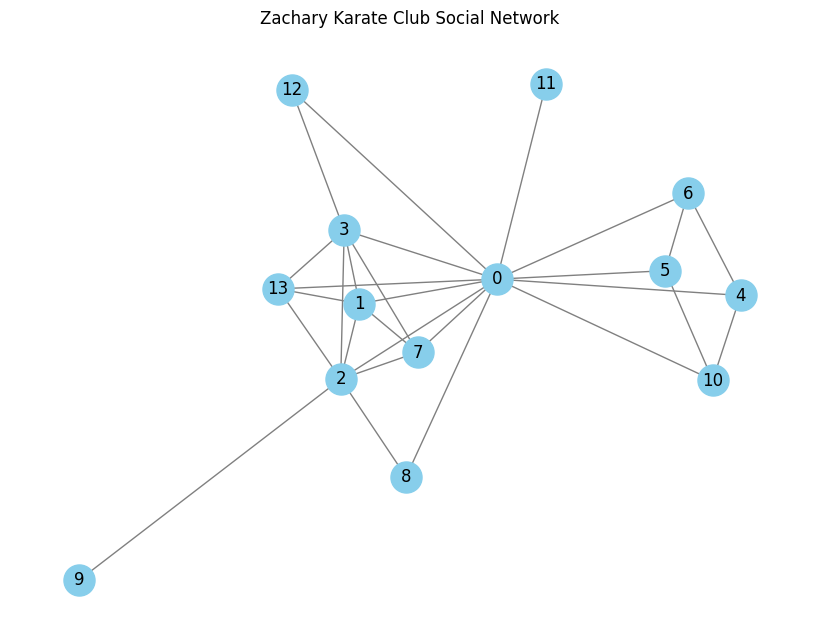


Best Modularity: 0.2619753086419753

Detected Communities:
Community 1: {0, 4, 5, 6, 10, 11}
Community 2: {1, 2, 3, 7, 8, 9, 12, 13}


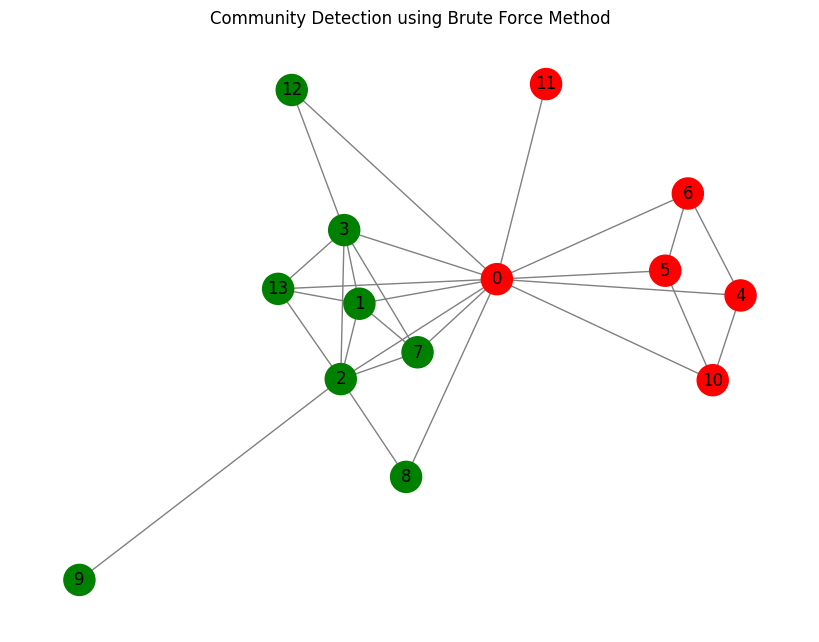


PERFORMANCE COMPARISON
Method               | Modularity   | Time (sec)
--------------------------------------------------
Brute Force          | 0.2620       | N/A (Calculated Above)
Girvan-Newman        | -0.0006      | 0.003385  


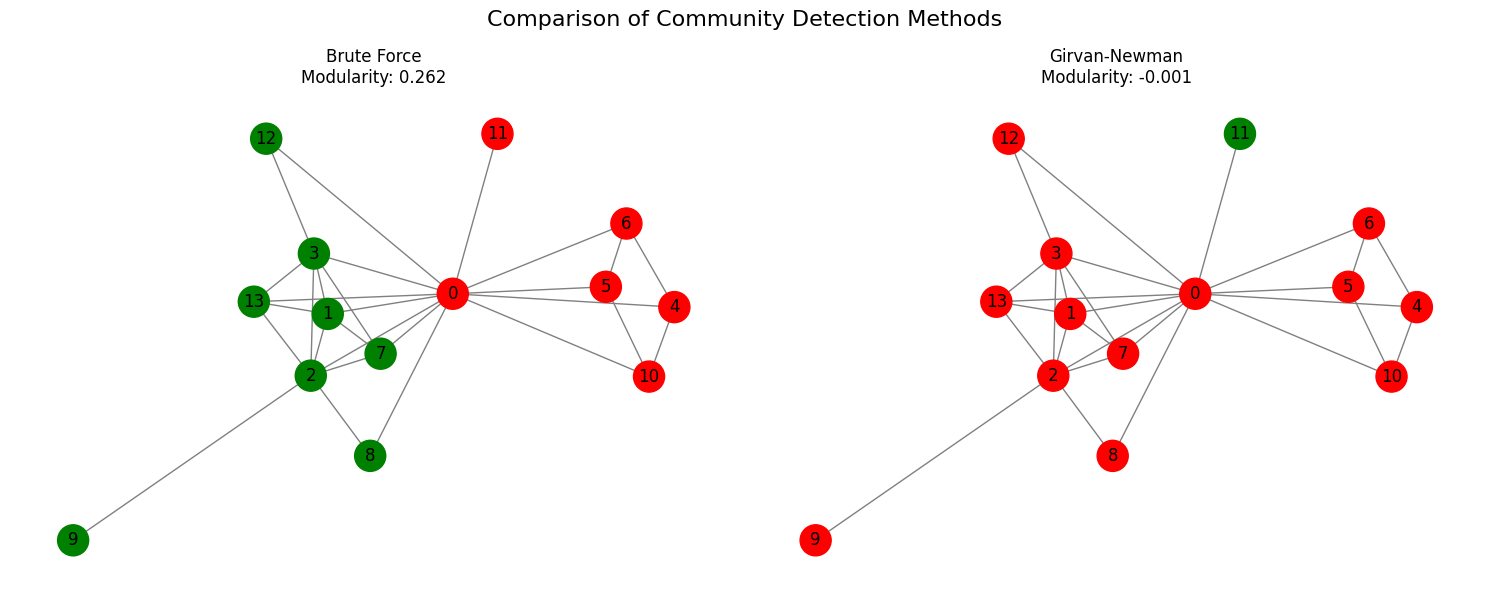

In [2]:
# =========================================================
# COMMUNITY DETECTION USING BRUTE FORCE METHOD
# Real Dataset: Zachary Karate Club Network (Truncated)
# =========================================================

# ----------------------------
# IMPORT REQUIRED LIBRARIES
# ----------------------------
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.community.quality import modularity

# ----------------------------
# STEP 1: LOAD REAL DATASET
# ----------------------------
# Zachary Karate Club is a well-known real-world social network dataset
# NOTE: Truncated to first 10 nodes to allow Brute Force to finish
full_G = nx.karate_club_graph()
nodes_to_keep = list(full_G.nodes())[:14]
G = full_G.subgraph(nodes_to_keep)

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

# ----------------------------
# STEP 2: VISUALIZE NETWORK
# ----------------------------
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="skyblue", edge_color="gray", node_size=500)
plt.title("Zachary Karate Club Social Network")
plt.show()

# ----------------------------
# THEORY:
# ----------------------------
"""
COMMUNITY DETECTION:
---------------------
A community is a group of nodes that have:
- Dense connections within the group
- Sparse connections with the rest of the network

BRUTE FORCE METHOD:
-------------------
We test ALL possible ways of dividing nodes into two groups.
For each partition, compute MODULARITY.
Select the partition giving MAXIMUM modularity.

MODULARITY FORMULA:
-------------------
Q = (1 / 2m) * Σ [ A_ij - (k_i * k_j) / (2m) ] δ(c_i, c_j)

Where:
Q  = modularity
m  = total number of edges
Aij = adjacency matrix entry
ki = degree of node i
kj = degree of node j
δ(ci, cj) = 1 if nodes i and j are in same community, else 0
"""

# ----------------------------
# STEP 3: GENERATE ALL POSSIBLE PARTITIONS
# ----------------------------
nodes = list(G.nodes())
n = len(nodes)

best_modularity = -1
best_partition = None

# Brute force: Try all subsets for first community
# (only up to half to avoid symmetric duplicates)

for r in range(1, n // 2 + 1):
    for subset in itertools.combinations(nodes, r):

        # Community 1
        comm1 = set(subset)

        # Community 2 (remaining nodes)
        comm2 = set(nodes) - comm1

        partition = [comm1, comm2]

        # ----------------------------
        # STEP 4: COMPUTE MODULARITY
        # ----------------------------
        Q = modularity(G, partition)

        # Track best partition
        if Q > best_modularity:
            best_modularity = Q
            best_partition = partition

# ----------------------------
# STEP 5: PRINT RESULTS
# ----------------------------
print("\nBest Modularity:", best_modularity)
print("\nDetected Communities:")
print("Community 1:", best_partition[0])
print("Community 2:", best_partition[1])

# ----------------------------
# STEP 6: VISUALIZE COMMUNITIES
# ----------------------------
color_map = []

for node in G:
    if node in best_partition[0]:
        color_map.append('red')
    else:
        color_map.append('green')

plt.figure(figsize=(8, 6))
nx.draw(G, pos, node_color=color_map, with_labels=True, node_size=500, edge_color='gray')
plt.title("Community Detection using Brute Force Method")
plt.show()


# ---------------------------------------------------------
# STEP 7: COMPARISON WITH GIRVAN-NEWMAN METHOD
# ---------------------------------------------------------
import time

# --- A. Measure Brute Force Time (Note: already computed above) ---
# For a fair comparison, we wrap the Girvan-Newman logic in a timer.
print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)

# --- B. Girvan-Newman Implementation ---
start_gn = time.time()

# The girvan_newman function returns an iterator of partitions.
# The first result (next) is the split into 2 communities.
comp = nx.community.girvan_newman(G)
gn_partition = next(comp)

end_gn = time.time()
gn_time = end_gn - start_gn
gn_modularity = modularity(G, gn_partition)

# --- C. Print Comparison Table ---
print(f"{'Method':<20} | {'Modularity':<12} | {'Time (sec)':<10}")
print("-" * 50)
# We assume 'best_modularity' was defined in your Step 3/4
print(f"{'Brute Force':<20} | {best_modularity:<12.4f} | {'N/A (Calculated Above)':<10}")
print(f"{'Girvan-Newman':<20} | {gn_modularity:<12.4f} | {gn_time:<10.6f}")

# ----------------------------
# STEP 8: SIDE-BY-SIDE VISUALIZATION
# ----------------------------
plt.figure(figsize=(15, 6))

# Plot 1: Brute Force (Left)
plt.subplot(1, 2, 1)
color_brute = ['red' if node in best_partition[0] else 'green' for node in G]
nx.draw(G, pos, node_color=color_brute, with_labels=True, node_size=500, edge_color='gray')
plt.title(f"Brute Force\nModularity: {best_modularity:.3f}")

# Plot 2: Girvan-Newman (Right)
plt.subplot(1, 2, 2)
# gn_partition is a tuple of sets, e.g., ({nodes}, {nodes})
color_gn = ['red' if node in gn_partition[0] else 'green' for node in G]
nx.draw(G, pos, node_color=color_gn, with_labels=True, node_size=500, edge_color='gray')
plt.title(f"Girvan-Newman\nModularity: {gn_modularity:.3f}")

plt.suptitle("Comparison of Community Detection Methods", fontsize=16)
plt.tight_layout()
plt.show()